In [1]:
import torch
print(torch.cuda.is_available())

True


In [2]:
!pip install kagglehub

import os
import torch
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from collections import Counter

In [7]:


# download dataset
path = kagglehub.dataset_download("abdallahalidev/plantvillage-dataset")

print("Dataset path:", path)

# navigate to correct folder
data_dir = os.path.join(path, "plantvillage dataset", "color")

# sanity check
print("Sample folders:", os.listdir(data_dir)[:5])

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Dataset path: /kaggle/input/plantvillage-dataset
Sample folders: ['Tomato___Late_blight', 'Tomato___healthy', 'Grape___healthy', 'Orange___Haunglongbing_(Citrus_greening)', 'Soybean___healthy']


In [8]:
transform = transforms.Compose([
    transforms.Resize((128, 128)),  # faster for now
    transforms.ToTensor()
])

dataset = datasets.ImageFolder(data_dir, transform=transform)

print("Total samples:", len(dataset))
print("Number of classes:", len(dataset.classes))

Total samples: 54305
Number of classes: 38


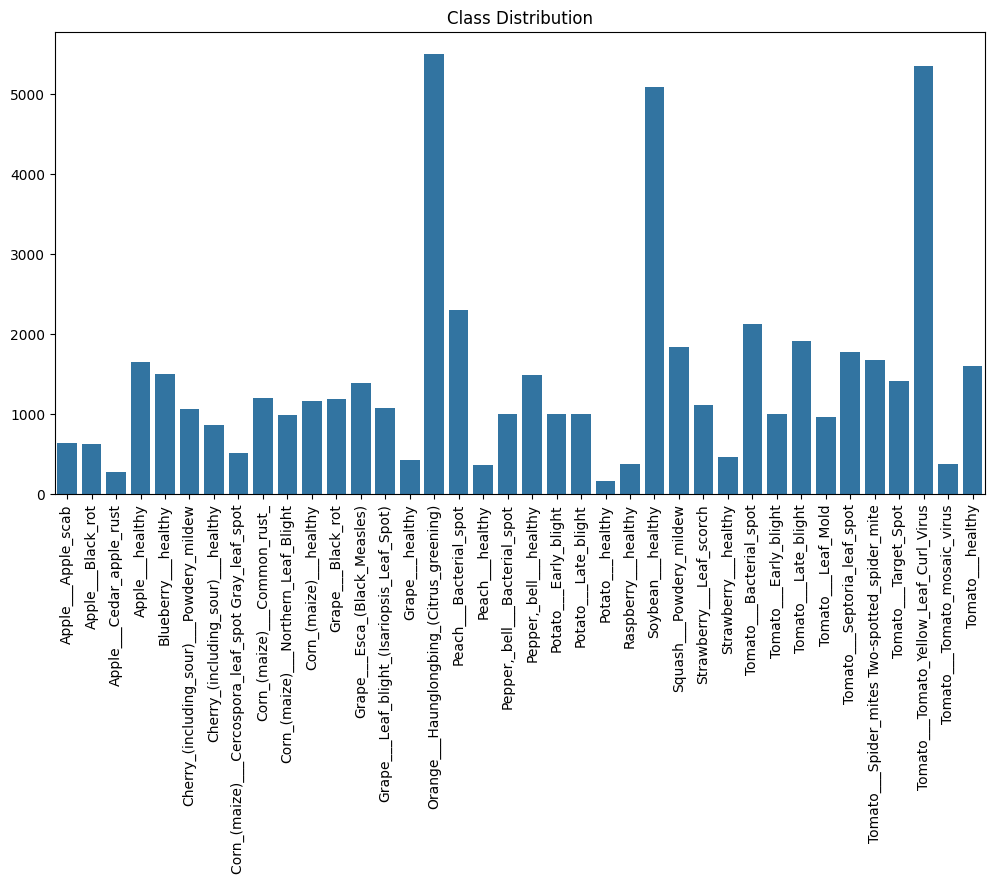

In [10]:
labels = dataset.targets
class_counts = Counter(labels)

class_names = dataset.classes
counts = [class_counts[i] for i in range(len(class_names))]

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12,6))
sns.barplot(x=class_names, y=counts)
plt.xticks(rotation=90)
plt.title("Class Distribution")
plt.show()

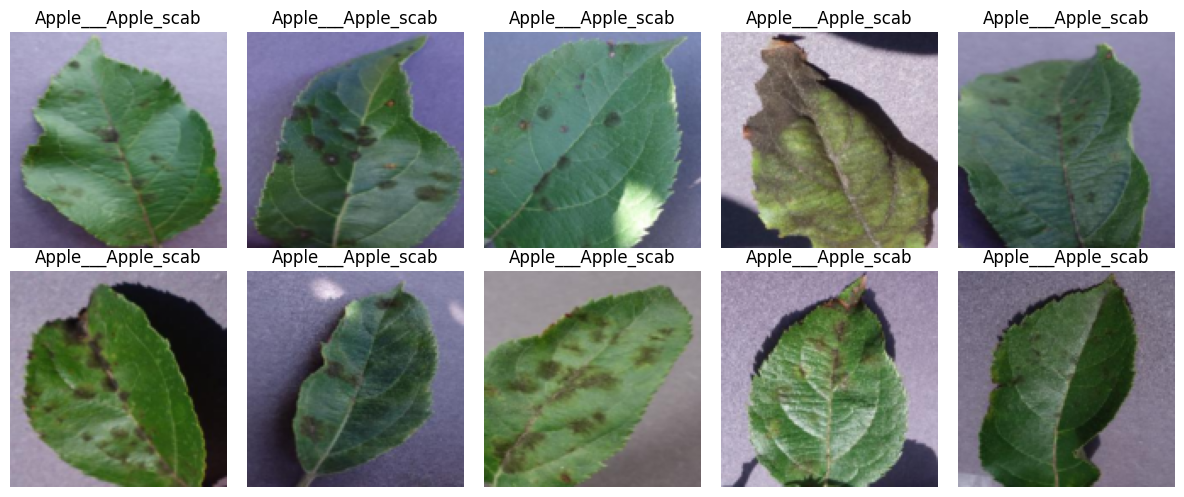

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(12,5))

for i, ax in enumerate(axes.flat):
    img, label = dataset[i]
    img = img.permute(1, 2, 0)  # CHW → HWC

    ax.imshow(img)
    ax.set_title(dataset.classes[label])
    ax.axis("off")

plt.tight_layout()
plt.show()

In [12]:
from torch.utils.data import random_split

train_size = int(0.7 * len(dataset))
val_size = int(0.15 * len(dataset))
test_size = len(dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_data, val_data, test_data = random_split(
    dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Train:", len(train_data))
print("Val:", len(val_data))
print("Test:", len(test_data))

Train: 38013
Val: 8145
Test: 8147
